In [1]:
import os
import glob

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

import model.clip.model as clip_model
from model.make_model_clipreid import load_clip_to_cpu

DATA_ROOT = '../../datasets'
MARKET = f'{DATA_ROOT}/Market-1501-v15.09.15'
MASKS = f'{DATA_ROOT}/market1501/masks/pifpaf_maskrcnn_filtering'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

/home/lakshh/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/lakshh/miniconda3/envs/py312/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


'cuda'

In [2]:
# Pretrained CLIP RN50 image encoder, built exactly like build_transformer does for RN50
# (make_model_clipreid.py:82-85): the attnpool positional embedding is resized to the 16x8 grid.
H, W = 384, 128            # INPUT.SIZE_TRAIN in configs/person/cnn_clipreid.yml
STRIDE = 16                # MODEL.STRIDE_SIZE
h_res, w_res = (H - 16) // STRIDE + 1, (W - 16) // STRIDE + 1   # -> 16, 8

clip = load_clip_to_cpu('RN50', h_res, w_res, STRIDE)
backbone = clip.visual.to(device).eval()   # ModifiedResNet with pretrained weights (fp32)
type(backbone).__name__, tuple(backbone.attnpool.positional_embedding.shape)

/home/lakshh/miniconda3/envs/py312/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Resized position embedding: %s to %s torch.Size([50, 2048]) torch.Size([193, 2048])
Position embedding resize to height:24 width: 8


('ModifiedResNet', (193, 2048))

In [3]:
# --- PifPaf mask preprocessing, self-contained copy of the BPBreID mask pipeline ---
# source: bpbreid/torchreid/data/masks_transforms/pifpaf_mask_transform.py:6-19
PIFPAF_KEYPOINTS = ["nose", "left_eye", "right_eye", "left_ear", "right_ear", "left_shoulder", "right_shoulder",
                    "left_elbow", "right_elbow", "left_wrist", "right_wrist", "left_hip", "right_hip", "left_knee",
                    "right_knee", "left_ankle", "right_ankle"]
PIFPAF_JOINTS = ["left_ankle_to_left_knee", "left_knee_to_left_hip", "right_ankle_to_right_knee",
                 "right_knee_to_right_hip", "left_hip_to_right_hip", "left_shoulder_to_left_hip",
                 "right_shoulder_to_right_hip", "left_shoulder_to_right_shoulder", "left_shoulder_to_left_elbow",
                 "right_shoulder_to_right_elbow", "left_elbow_to_left_wrist", "right_elbow_to_right_wrist",
                 "left_eye_to_right_eye", "nose_to_left_eye", "nose_to_right_eye", "left_eye_to_left_ear",
                 "right_eye_to_right_ear", "left_ear_to_left_shoulder", "right_ear_to_right_shoulder"]
PIFPAF_PARTS_MAP = {k: i for i, k in enumerate(PIFPAF_KEYPOINTS + PIFPAF_JOINTS)}

# source: CombinePifPafIntoFiveVerticalParts ('five_v'), pifpaf_mask_transform.py:211-232
FIVE_V = {
    "head": ["nose", "left_eye", "right_eye", "left_ear", "right_ear", "left_eye_to_right_eye",
             "nose_to_left_eye", "nose_to_right_eye", "left_eye_to_left_ear", "right_eye_to_right_ear",
             "left_ear_to_left_shoulder", "right_ear_to_right_shoulder"],
    "upper_arms_torso": ["left_elbow", "right_elbow", "left_shoulder_to_left_elbow", "right_shoulder_to_right_elbow",
                         "left_shoulder", "right_shoulder", "left_shoulder_to_right_shoulder"],
    "lower_arms_torso": ["left_wrist", "right_wrist", "left_elbow_to_left_wrist", "right_elbow_to_right_wrist",
                         "left_hip", "right_hip", "right_shoulder_to_right_hip"],
    "legs": ["left_hip", "right_hip", "left_knee", "right_knee", "left_ankle_to_left_knee", "left_knee_to_left_hip",
             "right_ankle_to_right_knee", "right_knee_to_right_hip"],
    "feet": ["left_ankle", "right_ankle"],
}
PART_NAMES = list(FIVE_V.keys())
K = len(PART_NAMES)   # 5 parts (+1 background channel)


def pifpaf_to_masks(raw, softmax_weight=15, threshold=0.5):
    """[36,H,W] PifPaf confidence fields -> [K+1,H,W] soft part distribution, channel 0 = background.
    = MaskGroupingTransform (max over grouped channels, mask_transform.py:31-38)
      + AddBackgroundMask('threshold', 15, 0.5) (mask_transform.py:60-85)."""
    raw = torch.as_tensor(raw, dtype=torch.float32)
    parts = torch.stack([raw[[PIFPAF_PARTS_MAP[k] for k in group]].max(0)[0].clamp(0, 1) for group in FIVE_V.values()])
    background = (parts.max(0)[0] < threshold).float()
    masks = torch.cat([background[None], parts])
    return F.softmax(masks * softmax_weight, dim=0)


def masks_to_targets(masks, size):
    """[N,K+1,H,W] soft masks -> [N,h,w] part-index targets at the feature-map size (part_based_engine.py:117-124)."""
    return F.interpolate(masks, size, mode='bilinear', align_corners=True).argmax(1)

In [4]:
# --- BPAM building blocks, copied from bpbreid/torchreid/models/bpbreid.py ---
class PixelToPartClassifier(nn.Module):
    """Pixel -> body-part classifier (bpbreid.py:376-396): BN2d + 1x1 conv to K+1 logits (0 = background)."""
    def __init__(self, dim, parts_num):
        super().__init__()
        self.bn = nn.BatchNorm2d(dim)
        self.classifier = nn.Conv2d(dim, parts_num + 1, kernel_size=1)
        nn.init.constant_(self.bn.weight, 1)
        nn.init.constant_(self.bn.bias, 0)
        nn.init.normal_(self.classifier.weight, 0, 0.001)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x):
        return self.classifier(self.bn(x))


def gwap(feat, masks):
    """Global weighted average pooling (GlobalWeightedAveragePoolingHead, bpbreid.py:489-503).
    feat [N,D,H,W], masks [N,M,H,W] -> [N,M,D] = sum_hw(mask*feat) / sum_hw(mask)."""
    num = torch.einsum('nmhw,ndhw->nmd', masks, feat)
    den = masks.sum((2, 3)).clamp(min=1e-6)[..., None]
    return num / den


def binary_visibility(probs):
    """Binary part visibility (bpbreid.py:181-192): a part is visible iff it wins the argmax at >=1 location."""
    one_hot = F.one_hot(probs.argmax(1), probs.shape[1]).permute(0, 3, 1, 2)
    return one_hot.amax((2, 3)).bool()   # [N,K+1]

In [5]:
class PartAwareModifiedResNet(nn.Module):
    """CLIP-ReID RN50 image encoder + BPBreID body-part attention (BPAM).

    * Backbone = the pretrained ModifiedResNet, untouched; (x3, x4, xproj) are returned with the same
      semantics as ModifiedResNet.forward so build_transformer would keep working unchanged.
    * A PixelToPartClassifier on x4 gives K part masks + background + visibility (BPBreID). Passing
      `external_masks` uses the PifPaf masks as attention instead (BPBreID `learnable_attention_enabled=False`).
    * Part embeddings in the CLIP joint space: CLIP's AttentionPool2d pools by attending a
      mean-of-locations query over the HW location tokens. We add one query per part (GWAP of x4 under
      the part mask) and one foreground query, and run the *same pretrained* q/k/v/c_proj attention.
      An additive mask lets each query attend only to itself + the locations, so query 0 reproduces
      the vanilla CLIP embedding xproj[0] exactly and parts do not disturb it.
    Only new parameters: the pixel classifier.
    """

    def __init__(self, backbone, parts_num=K):
        super().__init__()
        self.backbone = backbone
        self.parts_num = parts_num
        feat_dim = backbone.attnpool.k_proj.in_features   # 2048 for RN50
        self.pixel_classifier = PixelToPartClassifier(feat_dim, parts_num)

    def part_aware_attnpool(self, x4, queries):
        """queries [Q,N,C] (pooled from x4) attend over the HW locations of x4 with the pretrained
        attnpool weights (mirrors AttentionPool2d.forward, model/clip/model.py:66-90). -> [Q,N,output_dim]"""
        ap = self.backbone.attnpool
        loc = x4.flatten(2).permute(2, 0, 1)                       # [HW,N,C]
        pos = ap.positional_embedding[:, None, :].to(loc.dtype)     # [HW+1,1,C]
        q = queries + pos[:1]                                       # query tokens share the 'mean token' pos-embed
        kv = torch.cat([q, loc + pos[1:]], dim=0)                   # [Q+HW,N,C]
        Q = q.shape[0]
        attn_mask = torch.zeros(Q, kv.shape[0], device=x4.device, dtype=loc.dtype)
        attn_mask[:, :Q] = float('-inf')                            # queries never see each other...
        attn_mask.fill_diagonal_(0)                                 # ...except themselves (as in vanilla CLIP)
        out, _ = F.multi_head_attention_forward(
            query=q, key=kv, value=kv,
            embed_dim_to_check=q.shape[-1],
            num_heads=ap.num_heads,
            q_proj_weight=ap.q_proj.weight,
            k_proj_weight=ap.k_proj.weight,
            v_proj_weight=ap.v_proj.weight,
            in_proj_weight=None,
            in_proj_bias=torch.cat([ap.q_proj.bias, ap.k_proj.bias, ap.v_proj.bias]),
            bias_k=None, bias_v=None, add_zero_attn=False, dropout_p=0,
            out_proj_weight=ap.c_proj.weight,
            out_proj_bias=ap.c_proj.bias,
            use_separate_proj_weight=True,
            training=self.training,
            need_weights=False,
            attn_mask=attn_mask,
        )
        return out

    def forward(self, x, external_masks=None):
        b = self.backbone
        # --- identical to ModifiedResNet.forward (model/clip/model.py:133-148) ---
        x = x.type(b.conv1.weight.dtype)
        for conv, bn in [(b.conv1, b.bn1), (b.conv2, b.bn2), (b.conv3, b.bn3)]:
            x = b.relu(bn(conv(x)))
        x = b.avgpool(x)
        x = b.layer1(x)
        x = b.layer2(x)
        x3 = b.layer3(x)
        x4 = b.layer4(x3)
        xproj = b.attnpool(x4)                                      # vanilla [HW+1,N,1024]

        # --- BPAM: pixel -> part attention maps (BPBreID.forward, bpbreid.py:147-192) ---
        pixels_cls_scores = self.pixel_classifier(x4)               # [N,K+1,Hf,Wf]
        if external_masks is None:
            probs = pixels_cls_scores.softmax(1)
        else:                                                       # bpbreid.py:149-155
            probs = F.interpolate(external_masks, x4.shape[2:], mode='bilinear', align_corners=True)
        background_mask, parts_masks = probs[:, 0], probs[:, 1:]    # [N,Hf,Wf], [N,K,Hf,Wf]
        foreground_mask = parts_masks.max(1)[0]
        visibility = binary_visibility(probs)                       # [N,K+1] bool

        # --- BPBreID-style masked pooling on x4 (2048-d) ---
        part_emb_x4 = gwap(x4, parts_masks)                         # [N,K,2048]
        fg_emb_x4 = gwap(x4, foreground_mask[:, None])[:, 0]        # [N,2048]
        global_x4 = x4.mean((2, 3))                                 # = CLIP's mean query

        # --- part-aware CLIP attention pooling (1024-d, text-aligned space) ---
        queries = torch.cat([global_x4[None], fg_emb_x4[None], part_emb_x4.permute(1, 0, 2)], dim=0)  # [2+K,N,2048]
        pooled = self.part_aware_attnpool(x4, queries)              # [2+K,N,1024]

        parts_out = dict(
            pixels_cls_scores=pixels_cls_scores,
            parts_masks=parts_masks, background_mask=background_mask, foreground_mask=foreground_mask,
            visibility=visibility,
            part_emb_x4=part_emb_x4, fg_emb_x4=fg_emb_x4,
            global_clip=pooled[0], fg_emb_clip=pooled[1], part_emb_clip=pooled[2:].permute(1, 0, 2),  # [N,K,1024]
        )
        return x3, x4, xproj, parts_out


model = PartAwareModifiedResNet(backbone).to(device).eval()
sum(p.numel() for p in model.pixel_classifier.parameters()), 'new parameters (pixel classifier only)'

(16390, 'new parameters (pixel classifier only)')

In [6]:
# Real Market-1501 batch + matching PifPaf masks.
# Test-time transform of CLIP-ReID (datasets/make_dataloader_clipreid.py:54-58, PIXEL_MEAN/STD of cnn_clipreid.yml).
transform = T.Compose([T.Resize((H, W)), T.ToTensor(),
                       T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

img_paths = sorted(glob.glob(f'{MARKET}/bounding_box_train/*.jpg'))[:4]
imgs = torch.stack([transform(Image.open(p).convert('RGB')) for p in img_paths]).to(device)

raw_masks = [np.load(f'{MASKS}/bounding_box_train/{os.path.splitext(os.path.basename(p))[0]}.npy') for p in img_paths]
masks = torch.stack([pifpaf_to_masks(m) for m in raw_masks])      # [N,K+1,h,w] soft, sums to 1 per pixel
print('images', tuple(imgs.shape), '| raw pifpaf masks', raw_masks[0].shape, '| preprocessed masks', tuple(masks.shape))
[os.path.basename(p) for p in img_paths]

images (4, 3, 384, 128) | raw pifpaf masks (36, 17, 9) | preprocessed masks (4, 6, 17, 9)


['0002_c1s1_000451_03.jpg',
 '0002_c1s1_000551_01.jpg',
 '0002_c1s1_000776_01.jpg',
 '0002_c1s1_000801_01.jpg']

In [7]:
with torch.no_grad():
    x3, x4, xproj, out = model(imgs)                                   # learned (still untrained) BPAM masks
    _, _, _, out_ext = model(imgs, external_masks=masks.to(device))    # PifPaf masks as attention (BPBreID learnable_attention_enabled=False)

print('x3', tuple(x3.shape), '| x4', tuple(x4.shape), '| xproj', tuple(xproj.shape))
for k, v in out.items():
    print(f'{k:18s} {tuple(v.shape)}')

# 1) the global token is bit-for-bit the vanilla CLIP embedding used by CLIP-ReID (img_feature_proj = xproj[0])
diff = (out['global_clip'] - xproj[0]).abs().max().item()
assert torch.allclose(out['global_clip'], xproj[0], atol=1e-4), diff
assert torch.allclose(out_ext['global_clip'], xproj[0], atol=1e-4)
print(f'\nmax |global_clip - xproj[0]| = {diff:.2e}  (identical to vanilla CLIP-ReID feature, with or without parts)')

# 2) part tokens live in the same 1024-d CLIP space; with an untrained BPAM the masks are ~uniform so every
#    part query collapses to the global mean (cos ~ 1); with real PifPaf masks the parts are distinct.
def cos_parts_vs_global(o):
    pc = F.normalize(o['part_emb_clip'], dim=-1)
    g = F.normalize(o['global_clip'], dim=-1)[:, None].expand_as(pc)
    return torch.einsum('nkd,nkd->nk', pc, g).cpu().numpy().round(3)
print('cos(part_k, global) | untrained BPAM masks:\n', cos_parts_vs_global(out))
print('cos(part_k, global) | PifPaf masks:\n', cos_parts_vs_global(out_ext))
pc = F.normalize(out_ext['part_emb_clip'][0], dim=-1)
print('cos between parts (image 0, PifPaf masks):\n', (pc @ pc.T).cpu().numpy().round(3))

# 3) BPBreID binary visibility [background, *parts]
print('visibility (bg, ' + ', '.join(PART_NAMES) + ') | PifPaf masks:\n', out_ext['visibility'].int().cpu().numpy())

x3 (4, 1024, 24, 8) | x4 (4, 2048, 24, 8) | xproj (193, 4, 1024)
pixels_cls_scores  (4, 6, 24, 8)
parts_masks        (4, 5, 24, 8)
background_mask    (4, 24, 8)
foreground_mask    (4, 24, 8)
visibility         (4, 6)
part_emb_x4        (4, 5, 2048)
fg_emb_x4          (4, 2048)
global_clip        (4, 1024)
fg_emb_clip        (4, 1024)
part_emb_clip      (4, 5, 1024)

max |global_clip - xproj[0]| = 1.91e-06  (identical to vanilla CLIP-ReID feature, with or without parts)
cos(part_k, global) | untrained BPAM masks:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
cos(part_k, global) | PifPaf masks:
 [[0.888 0.947 0.969 0.974 0.951]
 [0.878 0.952 0.981 0.965 0.889]
 [0.944 0.971 0.979 0.983 0.933]
 [0.891 0.945 0.96  0.975 0.896]]
cos between parts (image 0, PifPaf masks):
 [[1.    0.894 0.876 0.865 0.835]
 [0.894 1.    0.98  0.941 0.847]
 [0.876 0.98  1.    0.967 0.89 ]
 [0.865 0.941 0.967 1.    0.932]
 [0.835 0.847 0.89  0.932 1.   ]]
visibility (bg, head, upper_

In [8]:
# Body-part attention supervision: PifPaf targets at the 16x8 feature-map resolution + pixel CE
# (BodyPartAttentionLoss, bpbreid/torchreid/losses/body_part_attention_loss.py:45-52; weight 0.35 in the GiLt config).
targets = masks_to_targets(masks.to(device), x4.shape[2:])          # [N,16,8] part indices, 0 = background
scores = out['pixels_cls_scores']                                   # [N,K+1,16,8]
pixel_loss = F.cross_entropy(scores.permute(0, 2, 3, 1).flatten(0, 2), targets.flatten(), label_smoothing=0.1)

print('targets', tuple(targets.shape), '| part pixel counts per image:\n',
      torch.stack([torch.bincount(t.flatten(), minlength=K + 1) for t in targets]).cpu().numpy())
print(f'pixel-part CE (untrained head, expect ~ln({K+1})={np.log(K+1):.3f}): {pixel_loss.item():.4f}'
      f'  | x0.35 = {0.35 * pixel_loss.item():.4f}')

targets (4, 24, 8) | part pixel counts per image:
 [[102   6  18  20  38   8]
 [ 93   5  35  24  26   9]
 [ 93   9  28  22  36   4]
 [108   8  21  19  31   5]]
pixel-part CE (untrained head, expect ~ln(6)=1.792): 1.7935  | x0.35 = 0.6277


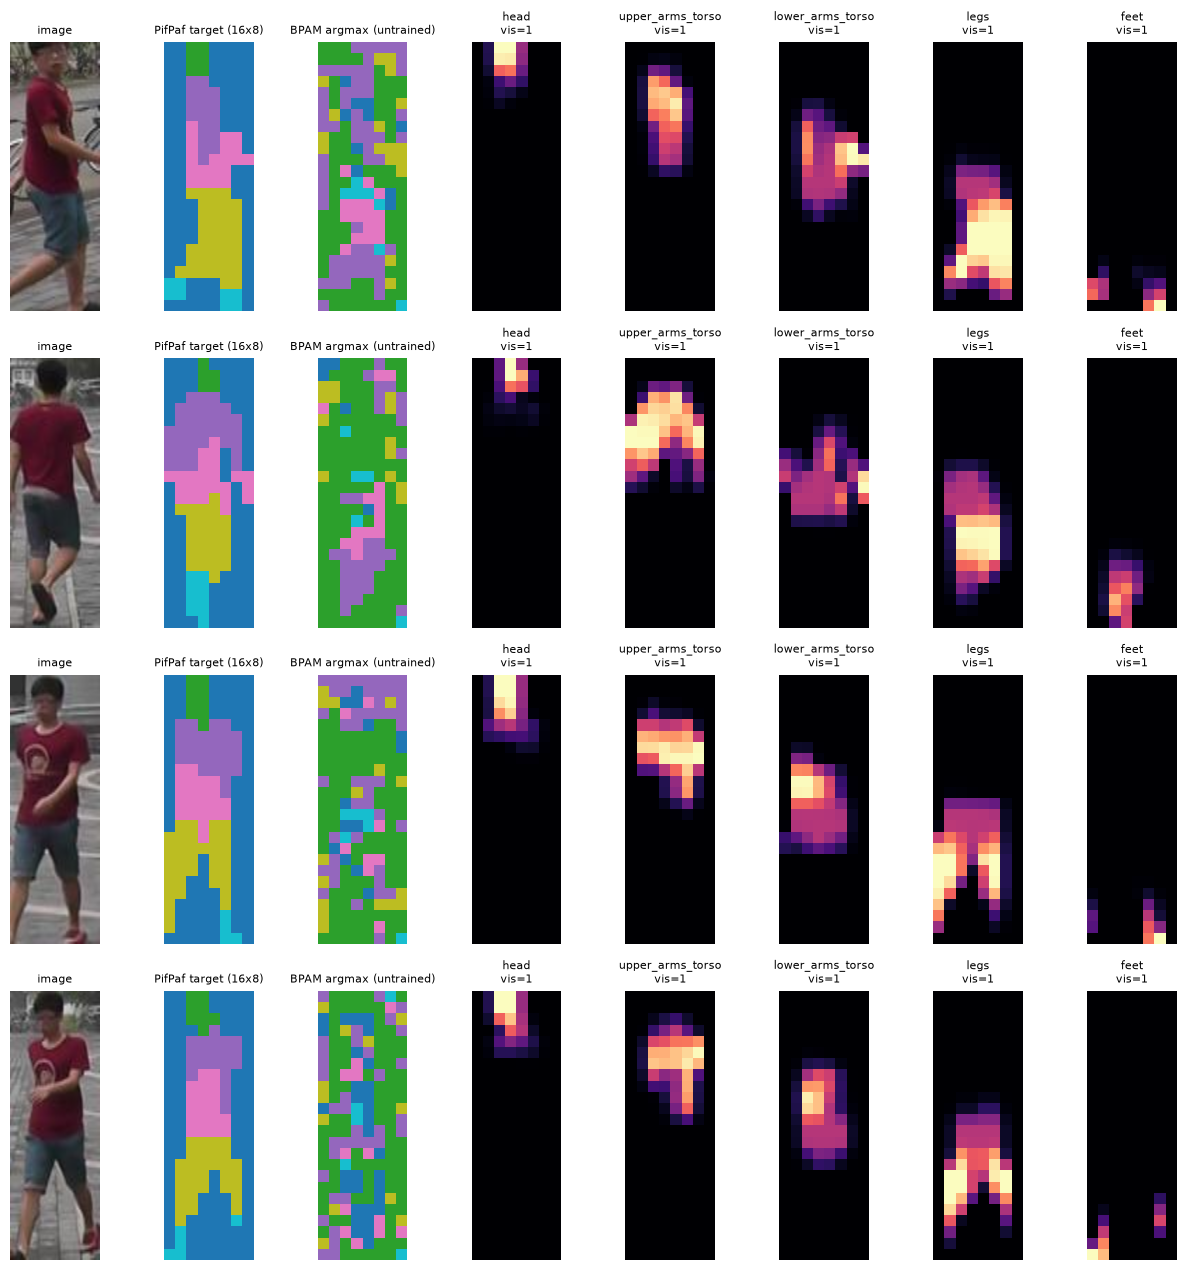

In [9]:
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406], device=t.device)[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=t.device)[:, None, None]
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

n = len(img_paths)
fig, axes = plt.subplots(n, 3 + K, figsize=(1.6 * (3 + K), 3.2 * n))
pred = scores.argmax(1)
for i in range(n):
    ax = axes[i]
    ax[0].imshow(denorm(imgs[i])); ax[0].set_title('image', fontsize=8)
    ax[1].imshow(targets[i].cpu(), vmin=0, vmax=K, cmap='tab10', interpolation='nearest'); ax[1].set_title('PifPaf target (16x8)', fontsize=8)
    ax[2].imshow(pred[i].cpu(), vmin=0, vmax=K, cmap='tab10', interpolation='nearest'); ax[2].set_title('BPAM argmax (untrained)', fontsize=8)
    for k in range(K):   # part attention maps actually used for pooling when the PifPaf masks drive the attention
        ax[3 + k].imshow(out_ext['parts_masks'][i, k].cpu(), vmin=0, vmax=1, cmap='magma', interpolation='nearest')
        ax[3 + k].set_title(f"{PART_NAMES[k]}\nvis={int(out_ext['visibility'][i, k + 1])}", fontsize=8)
    for a in ax:
        a.axis('off')
plt.tight_layout()
plt.show()

## What the encoder now exposes, and how it would plug into CLIP-ReID later (not implemented here)

`PartAwareModifiedResNet(x)` returns the unchanged `(x3, x4, xproj)` plus a dict:

| key | shape | meaning |
|---|---|---|
| `pixels_cls_scores` | `[N, K+1, 16, 8]` | BPAM logits, supervised with the PifPaf targets (pixel CE, weight 0.35) |
| `parts_masks` / `foreground_mask` / `background_mask` | `[N,K,16,8]` / `[N,16,8]` | soft part attention maps |
| `visibility` | `[N, K+1]` bool | BPBreID binary visibility (bg, head, upper torso, lower torso, legs, feet) |
| `part_emb_x4`, `fg_emb_x4` | `[N,K,2048]`, `[N,2048]` | BPBreID-faithful GWAP embeddings on `x4` |
| `global_clip` | `[N,1024]` | == `xproj[0]`, the feature CLIP-ReID already uses (`img_feature_proj`) |
| `fg_emb_clip`, `part_emb_clip` | `[N,1024]`, `[N,K,1024]` | foreground / per-part embeddings in the CLIP text-aligned space, via the pretrained attention pool |

Intended downstream use (future work, outside the image encoder):
* **Stage 2 losses** (`loss/make_loss.py`, `processor_clipreid_stage2.py`): keep the existing ID/triplet/i2t terms on the global features; add GiLt-style terms — ID on `fg_emb_x4`, part-averaged triplet on `part_emb_x4` (BPBreID default weights), and the pixel CE above.
* **Part-level image–text alignment**: `part_emb_clip @ text_features.T` gives per-part i2t logits, so the learned identity prompts can also be matched per body part; visibility can mask invisible parts out of the mean.
* **Retrieval**: concatenate `[global_clip | part_emb_clip]` and use BPBreID's visibility-aware mean of per-part distances (`bpbreid/torchreid/metrics/distance.py:131-178`) instead of a single global distance.

In [10]:
out.keys()

dict_keys(['pixels_cls_scores', 'parts_masks', 'background_mask', 'foreground_mask', 'visibility', 'part_emb_x4', 'fg_emb_x4', 'global_clip', 'fg_emb_clip', 'part_emb_clip'])

In [11]:
out['part_emb_x4'].shape

torch.Size([4, 5, 2048])

# Per-part CLIP alignment: global + K parts, each with its own learnable text prompt

Everything above stays as is. Below, each image gets K+1 = 6 embeddings (slot 0 = global, slots 1..5 = the
five body parts) and each identity gets 6 prompts with their own 4 learnable ctx tokens. The prompts are
learned exactly like CLIP-ReID stage 1 (i2t + t2i SupCon), just once per slot. No attention is added: the
global slot is the stock CLIP-ReID feature, parts are mask-pooled `x4` features passed through a linear map
derived from CLIP's own attention pool.

In [12]:
from model.clip.clip import tokenize
from model.make_model_clipreid import TextEncoder
from loss.supcontrast import SupConLoss

SLOT_NAMES = ['global'] + PART_NAMES
S = K + 1


class PartPromptLearner(nn.Module):
    """Learnable prompts for every (identity, slot) pair; slot 0 = global, slots 1..K = body parts.

    Design decisions
    * One shared text encoder. CLIP's text encoder stays frozen (as in CLIP-ReID stage 1), so two encoders
      would be two identical copies; the global and part prompts are told apart by their template words
      and by their own ctx tokens instead.
    * Templates: slot 0 keeps CLIP-ReID's "A photo of a X X X X person.", slot k uses
      "A photo of the <part name> of a X X X X person.".
    * ctx = cls_ctx[num_class, K+1, 4, 512]: each identity owns 4 learnable tokens per slot, i.e. the
      CLIP-ReID ctx (4) expanded to (K+1) x 4. Only these tensors are trained.
    * Templates have different lengths, so the position of the X tokens is found per template by
      tokenising; prefix/suffix embeddings are stored per slot (mirrors PromptLearner in
      make_model_clipreid.py:191-233).
    forward(label [B], slots=None) -> prompts [B*len(slots), 77, 512], tokenized [B*len(slots), 77]
    (slot-minor order; slots=None means all K+1 slots).
    """

    def __init__(self, num_class, clip_model, part_names, n_ctx=4):
        super().__init__()
        templates = ['A photo of a X X X X person.'] + [f"A photo of the {p.replace('_', ' ')} of a X X X X person." for p in part_names]
        tokenized = tokenize(templates).to(clip_model.token_embedding.weight.device)
        with torch.no_grad():
            embedding = clip_model.token_embedding(tokenized).type(clip_model.dtype)
        x_id = tokenize('X')[0, 1].item()
        self.templates = templates
        self.num_slots = len(templates)
        self.n_ctx = n_ctx
        self.register_buffer('tokenized', tokenized)
        for s in range(self.num_slots):
            x0 = (tokenized[s] == x_id).nonzero()[0].item()
            self.register_buffer(f'prefix_{s}', embedding[s, :x0].clone())
            self.register_buffer(f'suffix_{s}', embedding[s, x0 + n_ctx:].clone())
        ctx = torch.empty(num_class, self.num_slots, n_ctx, embedding.shape[-1], dtype=clip_model.dtype)
        nn.init.normal_(ctx, std=0.02)
        self.cls_ctx = nn.Parameter(ctx)

    def forward(self, label, slots=None):
        slots = range(self.num_slots) if slots is None else slots
        b = label.shape[0]
        ctx = self.cls_ctx[label]
        prompts = []
        for s in slots:
            prefix = getattr(self, f'prefix_{s}')[None].expand(b, -1, -1)
            suffix = getattr(self, f'suffix_{s}')[None].expand(b, -1, -1)
            prompts.append(torch.cat([prefix, ctx[:, s], suffix], dim=1))
        prompts = torch.stack(prompts, dim=1).flatten(0, 1)
        tokenized = self.tokenized[list(slots)][None].expand(b, -1, -1).flatten(0, 1)
        return prompts, tokenized


clip = clip.to(device).eval()
for p in clip.parameters():
    p.requires_grad_(False)
text_encoder = TextEncoder(clip).to(device).eval()


def encode_text(prompt_learner, label, slots=None):
    """label [B] -> text_feats [B, len(slots), 1024] through the shared frozen CLIP text encoder."""
    prompts, tokenized = prompt_learner(label, slots)
    return text_encoder(prompts, tokenized).view(label.shape[0], -1, text_encoder.text_projection.shape[1])


_pl = PartPromptLearner(3, clip, PART_NAMES).to(device)
with torch.no_grad():
    _tf = encode_text(_pl, torch.tensor([0, 1, 2], device=device))
print('\n'.join(_pl.templates))
print('cls_ctx', tuple(_pl.cls_ctx.shape), '| text_feats', tuple(_tf.shape))
del _pl, _tf

A photo of a X X X X person.
A photo of the head of a X X X X person.
A photo of the upper arms torso of a X X X X person.
A photo of the lower arms torso of a X X X X person.
A photo of the legs of a X X X X person.
A photo of the feet of a X X X X person.
cls_ctx (3, 6, 4, 512) | text_feats (3, 6, 1024)


In [13]:
class PartImageEncoder(nn.Module):
    """Image side of the per-part alignment: one 1024-d CLIP-space embedding per slot, no attention added.

    Design decisions
    * slot 0 (global) = xproj[0], the stock CLIP-ReID image feature (img_feature_proj), untouched.
    * slot k (part)   = gwap(x4, mask_k) in 2048-d, then a Linear(2048 -> 1024) whose weights are derived
      from CLIP's own attention pool: W = c_proj.W @ v_proj.W, b = c_proj.W @ v_proj.b + c_proj.b.
      This is the attention pool's value -> output path with the attention weights replaced by the part
      mask, so the part embeddings land in CLIP's joint space using only pretrained weights.
    * The projection is frozen and the backbone is frozen: like CLIP-ReID stage 1, only the text ctx learns.
    * Masks come from PifPaf (BPBreID learnable_attention_enabled=False), because the BPAM head is not
      trained in this setting; pooling reuses PartAwareModifiedResNet(x, external_masks=...).
    * visibility = BPBreID binary rule on the same masks, [N, K+1] with slot 0 always visible.
    forward(x, masks) -> img_feats [N, K+1, 1024], visibility [N, K+1] bool.
    """

    def __init__(self, part_aware_backbone):
        super().__init__()
        self.net = part_aware_backbone
        ap = part_aware_backbone.backbone.attnpool
        self.part_proj = nn.Linear(ap.v_proj.in_features, ap.c_proj.out_features)
        with torch.no_grad():
            self.part_proj.weight.copy_(ap.c_proj.weight @ ap.v_proj.weight)
            self.part_proj.bias.copy_(ap.c_proj.weight @ ap.v_proj.bias + ap.c_proj.bias)
        for p in self.parameters():
            p.requires_grad_(False)

    def forward(self, x, masks):
        _, _, xproj, out = self.net(x, external_masks=masks)
        parts = self.part_proj(out['part_emb_x4'])
        img_feats = torch.cat([xproj[0][:, None], parts], dim=1)
        visibility = out['visibility'].clone()
        visibility[:, 0] = True
        return img_feats, visibility


image_encoder = PartImageEncoder(model).to(device).eval()
with torch.no_grad():
    _f, _v = image_encoder(imgs, masks.to(device))
print('img_feats', tuple(_f.shape), '| visibility', tuple(_v.shape))
assert torch.allclose(_f[:, 0], xproj[0], atol=1e-4)
del _f, _v

img_feats (4, 6, 1024) | visibility (4, 6)


In [14]:
import re

NUM_IDS = 32
BATCH = 32


def load_subset(split='bounding_box_train', num_ids=NUM_IDS):
    """First `num_ids` identities of a Market-1501 split (Market1501.process_dir id parsing) with their
    PifPaf masks. Returns image paths, relabelled ids [N] and preprocessed masks [N, K+1, h, w]."""
    pattern = re.compile(r'([-\d]+)_c(\d)')
    paths, pids = [], []
    for p in sorted(glob.glob(f'{MARKET}/{split}/*.jpg')):
        pid = int(pattern.search(p).group(1))
        if pid == -1:
            continue
        paths.append(p)
        pids.append(pid)
    keep_pids = sorted(set(pids))[:num_ids]
    pid2label = {pid: i for i, pid in enumerate(keep_pids)}
    sel = [i for i, pid in enumerate(pids) if pid in pid2label]
    paths = [paths[i] for i in sel]
    labels = torch.tensor([pid2label[pids[i]] for i in sel])
    masks = torch.stack([pifpaf_to_masks(np.load(f'{MASKS}/{split}/{os.path.splitext(os.path.basename(p))[0]}.npy')) for p in paths])
    return paths, labels, masks


@torch.no_grad()
def extract_features(paths, masks):
    """Frozen image side, run once and cached (CLIP-ReID stage 1 caches image features the same way,
    processor_clipreid_stage1.py:43-53). Returns img_feats [N, K+1, 1024], visibility [N, K+1]."""
    feats, vis = [], []
    for i in range(0, len(paths), BATCH):
        x = torch.stack([transform(Image.open(p).convert('RGB')) for p in paths[i:i + BATCH]]).to(device)
        f, v = image_encoder(x, masks[i:i + BATCH].to(device))
        feats.append(f)
        vis.append(v)
    return torch.cat(feats), torch.cat(vis)


sub_paths, sub_labels, sub_masks = load_subset()
sub_labels = sub_labels.to(device)
sub_feats, sub_vis = extract_features(sub_paths, sub_masks)
print(f'{len(sub_paths)} images, {NUM_IDS} identities | img_feats {tuple(sub_feats.shape)} | visibility {tuple(sub_vis.shape)}')
print('visible fraction per slot:', dict(zip(SLOT_NAMES, sub_vis.float().mean(0).cpu().numpy().round(3))))

522 images, 32 identities | img_feats (522, 6, 1024) | visibility (522, 6)
visible fraction per slot: {'global': np.float32(1.0), 'head': np.float32(0.866), 'upper_arms_torso': np.float32(0.979), 'lower_arms_torso': np.float32(0.966), 'legs': np.float32(0.927), 'feet': np.float32(0.73)}


chance = 0.031
image->text top-1 accuracy BEFORE alignment: {'global': 0.013, 'head': 0.031, 'upper_arms_torso': 0.033, 'lower_arms_torso': 0.044, 'legs': 0.029, 'feet': 0.055}


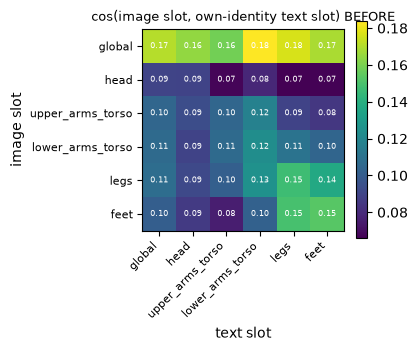

In [15]:
@torch.no_grad()
def all_text_feats(prompt_learner):
    """Text features of every identity and slot: [num_class, K+1, 1024]."""
    return encode_text(prompt_learner, torch.arange(prompt_learner.cls_ctx.shape[0], device=device))


@torch.no_grad()
def slot_accuracy(img_feats, labels, vis, text_all):
    """Image -> text top-1 identity accuracy per slot: does the slot-k image embedding pick its own
    identity's slot-k prompt among all identities? Invisible parts are skipped."""
    acc = {}
    for s, name in enumerate(SLOT_NAMES):
        keep = vis[:, s]
        sims = F.normalize(img_feats[keep, s], dim=-1) @ F.normalize(text_all[:, s], dim=-1).T
        acc[name] = (sims.argmax(1) == labels[keep]).float().mean().item()
    return acc


@torch.no_grad()
def cross_slot_matrix(img_feats, labels, text_all):
    """[K+1, K+1] mean cosine between image slot i and the same identity's text slot j.
    A diagonal-dominant matrix means each part is aligned to its own prompt, not just to the identity."""
    own_text = F.normalize(text_all[labels], dim=-1)
    img = F.normalize(img_feats, dim=-1)
    return torch.einsum('nid,njd->ij', img, own_text).div(len(labels)).cpu().numpy()


def show_matrix(m, title):
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(m, cmap='viridis')
    ax.set_xticks(range(S)); ax.set_xticklabels(SLOT_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(S)); ax.set_yticklabels(SLOT_NAMES, fontsize=8)
    ax.set_xlabel('text slot'); ax.set_ylabel('image slot'); ax.set_title(title, fontsize=9)
    for i in range(S):
        for j in range(S):
            ax.text(j, i, f'{m[i, j]:.2f}', ha='center', va='center', fontsize=6, color='w')
    plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


torch.manual_seed(0)
prompt_learner = PartPromptLearner(NUM_IDS, clip, PART_NAMES).to(device)
text_before = all_text_feats(prompt_learner)
acc_before = slot_accuracy(sub_feats, sub_labels, sub_vis, text_before)
print(f'chance = {1 / NUM_IDS:.3f}')
print('image->text top-1 accuracy BEFORE alignment:', {k: round(v, 3) for k, v in acc_before.items()})
show_matrix(cross_slot_matrix(sub_feats, sub_labels, text_before), 'cos(image slot, own-identity text slot) BEFORE')

epoch   1/30  loss 57.9888


epoch   5/30  loss 29.2100


epoch  10/30  loss 23.1210


epoch  15/30  loss 20.2683


epoch  20/30  loss 19.1240


epoch  25/30  loss 18.2169


epoch  30/30  loss 18.0120


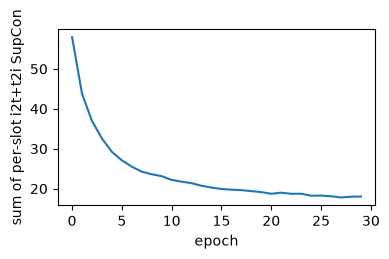

In [16]:
def align_prompts(prompt_learner, img_feats, labels, vis, epochs=30, batch=64, lr=3.5e-4, weight_decay=1e-4, log_every=5):
    """CLIP-ReID stage 1, applied per slot (processor_clipreid_stage1.py:60-86).

    * Image side frozen and cached; only prompt_learner.cls_ctx is optimised (Adam, stage-1 lr / wd,
      constant lr instead of the warmup-cosine schedule to keep the cell short).
    * loss = sum over slots k of SupCon(img_k, text_k) + SupCon(text_k, img_k) with the repo's SupConLoss,
      so i2t / t2i are used only to pull each identity's slot-k prompt to its slot-k image embeddings.
    * Each slot is encoded and back-propagated on its own (gradient accumulation): the slots share no
      parameters, so this equals one backward on the summed loss but needs 1/(K+1) of the memory.
    * Visibility gating: images whose part k is invisible are dropped from slot k's loss. An invisible
      part pools to a meaningless vector, so aligning a prompt to it would only add noise.
    Returns the per-epoch loss history.
    """
    xent = SupConLoss(device)
    optimizer = torch.optim.Adam(prompt_learner.parameters(), lr=lr, weight_decay=weight_decay)
    n = len(labels)
    history = []
    for epoch in range(1, epochs + 1):
        prompt_learner.train()
        perm = torch.randperm(n, device=device)
        total, count = 0.0, 0
        for i in range(0, n, batch):
            b = perm[i:i + batch]
            target, img_b, vis_b = labels[b], img_feats[b], vis[b]
            optimizer.zero_grad()
            batch_loss = 0.0
            for s in range(S):
                keep = vis_b[:, s]
                if keep.sum() < 2:
                    continue
                text_s = encode_text(prompt_learner, target[keep], slots=[s])[:, 0]
                loss = xent(img_b[keep, s], text_s, target[keep], target[keep]) \
                     + xent(text_s, img_b[keep, s], target[keep], target[keep])
                loss.backward()
                batch_loss += loss.item()
            optimizer.step()
            total += batch_loss * len(b)
            count += len(b)
        history.append(total / count)
        if epoch % log_every == 0 or epoch == 1:
            print(f'epoch {epoch:3d}/{epochs}  loss {history[-1]:.4f}')
    prompt_learner.eval()
    return history


loss_history = align_prompts(prompt_learner, sub_feats, sub_labels, sub_vis)
plt.figure(figsize=(4, 2.5)); plt.plot(loss_history); plt.xlabel('epoch'); plt.ylabel('sum of per-slot i2t+t2i SupCon'); plt.tight_layout(); plt.show()

chance = 0.031
image->text top-1 accuracy per slot (before -> after):
  global             0.013 -> 0.966
  head               0.031 -> 0.973
  upper_arms_torso   0.033 -> 0.969
  lower_arms_torso   0.044 -> 0.986
  legs               0.029 -> 0.981
  feet               0.055 -> 0.984


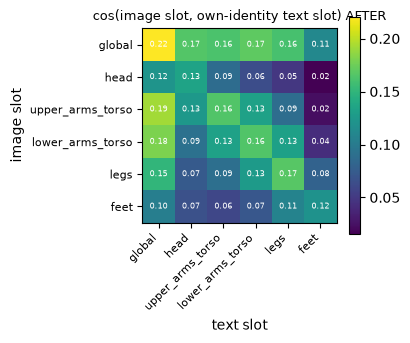

per image slot: cos to own text slot vs mean cos to the other slots
  global             own 0.220   others 0.154   margin +0.067
  head               own 0.134   others 0.068   margin +0.067
  upper_arms_torso   own 0.165   others 0.112   margin +0.053
  lower_arms_torso   own 0.164   others 0.116   margin +0.049
  legs               own 0.167   others 0.104   margin +0.063
  feet               own 0.120   others 0.081   margin +0.039


In [17]:
text_after = all_text_feats(prompt_learner)
acc_after = slot_accuracy(sub_feats, sub_labels, sub_vis, text_after)
print(f'chance = {1 / NUM_IDS:.3f}')
print('image->text top-1 accuracy per slot (before -> after):')
for name in SLOT_NAMES:
    print(f'  {name:18s} {acc_before[name]:.3f} -> {acc_after[name]:.3f}')

m_after = cross_slot_matrix(sub_feats, sub_labels, text_after)
show_matrix(m_after, 'cos(image slot, own-identity text slot) AFTER')
diag = np.diag(m_after)
off = (m_after.sum(1) - diag) / (S - 1)
print('per image slot: cos to own text slot vs mean cos to the other slots')
for name, d, o in zip(SLOT_NAMES, diag, off):
    print(f'  {name:18s} own {d:.3f}   others {o:.3f}   margin {d - o:+.3f}')

## Results, per-part visibility, and what is still open

**Alignment result (32 identities, 522 images).** Image→text top-1 identity accuracy per slot goes from
chance (~3%) to 97–99% for the global slot and all five part slots. In the cross-slot matrix every image
part is closer to its own prompt than to the other *part* prompts. One caveat to keep in mind: for the two
torso slots the *global* prompt scores slightly higher than their own prompt — the torso dominates the
global image feature, so the global prompt naturally attracts it. Whether this matters is a matching-time
question (below).

**How BPBreID uses visibility.**
* Computed from the part maps: a part is *visible* iff it wins the argmax at at least one feature-map
  location (`bpbreid.py:181-192`); that rule is reused here (`binary_visibility`).
* **Training:** by default it is *not* a gate — `mask_filtering_training=False`, so id/triplet losses see
  every part. It is only used to filter losses when that flag is on.
* **Matching (where its gains come from):** per-part distances are averaged only over parts visible in
  *both* query and gallery (`compute_distance_matrix_using_bp_features`, `metrics/distance.py:131-178`);
  a pair with no common visible part gets the worst distance. This is what makes the method robust to
  occlusion, and it is where BPBreID reports its improvements (Occluded-Duke, Occluded-ReID).

**What was done here.** Visibility is used as a gate in the alignment loss only (an invisible part pools to
a meaningless vector, so its prompt should not be pulled towards it). On this Market-1501 subset it is not a
no-op: feet are visible in ~73% of images and the head in ~87%, so those prompts were trained on fewer
samples — but its effect on retrieval cannot be measured in this notebook.

**To be figured out (at matching time).** Not settled here; decide once retrieval is built:
1. BPBreID-style mutual-visibility mean of per-slot distances (global + parts), vs.
2. visibility-*weighted* mean (soft, uses `probs.amax` instead of the binary rule), vs.
3. ignore visibility and rely on the global slot only.
Also open: whether the global slot should always be in the average or only be a fallback when no part is
shared, and whether text-side matching (image slot k vs. prompt slot k) should be part of the distance at
all or only used for training the prompts.

1. plan to evaluate as per part (bpbreid style, im giving the workdirs folder from the training server, run an evaluation test from part based matching, not one global vector based)

comparison also per_part (head to head, leg to leg etc) vs pooled_global